# Deploy "the best" Time-Series Forecasting model 

**Requirements** - In order to benefit from this tutorial, you will need:
- A basic understanding of Machine Learning
- An Azure account with an active subscription. [Create an account for free](https://azure.microsoft.com/free/?WT.mc_id=A261C142F)
- An Azure ML workspace. [Check this notebook for creating a workspace](../../../resources/workspace/workspace.ipynb)
- A python environment
- Installed Azure Machine Learning Python SDK v2 - [install instructions](../../../README.md) - check the getting started section

**Learning Objectives** - By the end of this tutorial, you should be able to:
- Connect to your AML workspace from the Python SDK
- Create an `AutoML time-series forecasting Job` with the 'forecasting()' factory-fuction.
- Train the model using [serverless compute (preview)](https://learn.microsoft.com/azure/machine-learning/how-to-use-serverless-compute?view=azureml-api-2&tabs=python) by submitting/running the AutoML forecasting training job
- Obtaing the model and score predictions with it

**Motivations** - This notebook explains how to setup and run an AutoML forecasting job. This is one of the nine ML-tasks supported by AutoML. Other ML-tasks are 'regression', 'classification', 'image classification', 'image object detection', 'nlp text classification', etc.


# 1. Connect to Azure Machine Learning Workspace

The [workspace](https://docs.microsoft.com/en-us/azure/machine-learning/concept-workspace) is the top-level resource for Azure Machine Learning, providing a centralized place to work with all the artifacts you create when you use Azure Machine Learning. In this section we will connect to the workspace in which the job will be run.

## 1.1. Import the required libraries

In [1]:
# Import required libraries
from azure.identity import DefaultAzureCredential
from azure.ai.ml import MLClient

from azure.ai.ml.constants import AssetTypes, InputOutputModes
from azure.ai.ml import automl
from azure.ai.ml import Input
import os
from dotenv import load_dotenv
import pandas as pd
import mltable

In [2]:
# Import required libraries
from azure.identity import DefaultAzureCredential
from azure.ai.ml import MLClient

from azure.ai.ml.constants import AssetTypes, InputOutputModes
from azure.ai.ml import automl
from azure.ai.ml import Input
import os
from dotenv import load_dotenv
import pandas as pd
import mltable

## 1.2. Configure workspace details and get a handle to the workspace

To connect to a workspace, we need identifier parameters - a subscription, resource group and workspace name. We will use these details in the `MLClient` from `azure.ai.ml` to get a handle to the required Azure Machine Learning workspace. We use the default [default azure authentication](https://docs.microsoft.com/en-us/python/api/azure-identity/azure.identity.defaultazurecredential?view=azure-python) for this tutorial. Check the [configuration notebook](../../configuration.ipynb) for more details on how to configure credentials and connect to a workspace.

In [3]:
load_dotenv()
subscription_id = os.environ.get("subscription")
resource_group = os.environ.get("resource_group")
workspace = os.environ.get("workspace")

In [4]:
credential = DefaultAzureCredential()
ml_client = None
try:
    ml_client = MLClient.from_config(credential)
except Exception as ex:
    print(ex)
    # Enter details of your AML workspace
    subscription_id = subscription_id
    resource_group = resource_group
    workspace = workspace

    ml_client = MLClient(credential, subscription_id, resource_group, workspace)

Found the config file in: C:\Users\karinaa\OneDrive - Microsoft\Documents\codes\azure-samples\.azureml\config.json


### Show Azure ML Workspace information

In [ ]:
workspace = ml_client.workspaces.get(name=ml_client.workspace_name)

output = {}
output["Workspace"] = ml_client.workspace_name
output["Subscription ID"] = ml_client.subscription_id
output["Resource Group"] = workspace.resource_group
output["Location"] = workspace.location
pd.set_option("display.max_colwidth", None)
outputDf = pd.DataFrame(data=output, index=[""])
outputDf.T

# 2. Retrieve the Best Trial (Best Model's trial/run)
Use the MLFLowClient to access the results (such as Models, Artifacts, Metrics) of a previously completed AutoML Trial.

## 2.1 Initialize MLFlow Client
The models and artifacts that are produced by AutoML can be accessed via the MLFlow interface.
Initialize the MLFlow client here, and set the backend as Azure ML, via. the MLFlow Client.

*IMPORTANT*, you need to have installed the latest MLFlow packages with:

    pip install azureml-mlflow

    pip install mlflow

### Obtain the tracking URI for MLFlow

In [ ]:
import mlflow

# Obtain the tracking URL from MLClient
MLFLOW_TRACKING_URI = ml_client.workspaces.get(
    name=ml_client.workspace_name
).mlflow_tracking_uri

print(MLFLOW_TRACKING_URI)

In [ ]:
# Set the MLFLOW TRACKING URI

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

print("\nCurrent tracking uri: {}".format(mlflow.get_tracking_uri()))

In [8]:
from mlflow.tracking.client import MlflowClient
from mlflow.artifacts import download_artifacts

# Initialize MLFlow client
mlflow_client = MlflowClient()

### Get the AutoML parent Job

In [9]:
jobs = ml_client.jobs.list()
job_names = [job.name for job in jobs]
print("List of all jobs:")
for name in job_names:
    print(name)

List of all jobs:
forecasting20250527
batchjob-7ad45584-48bf-42e2-8cc5-b23c55b14863
batchjob-300d790a-82bb-48ab-b4db-62f36657d32b
forecasting20250506
batchjob-6adcf578-021b-4f02-a6e2-51b393ff29b9
batchjob-a2f1753b-32fe-4488-a8a1-a951316ac6c6
batchjob-6c45cf51-e63b-413e-f919-79689a38f6f0
batchjob-29c4c245-7791-5c2a-53f0-a27b98726328
batchjob-9affed1b-f31d-c351-7476-95f3d8b9e1db
batchjob-f42e9292-8dbf-fb65-57b0-3143c018f250
batchjob-ab1222c4-afa5-c038-26fa-f05d8649c3bc
batchjob-22b00b54-8ba1-4904-95b1-544f46eef80a
5acaea8d-2dfb-4ff9-8d34-dd85127366aa
imgbldrun_ce037d8
batchjob-c6f077ea-1d3a-6edf-10cc-0c6774622183
imgbldrun_410c93b
next_30_days
test2
forecasting_call_center


In [10]:
job_name = "forecasting20250527"

# Example if providing an specific Job name/ID
# job_name = returned_job.name

In [11]:
# Get the parent run
mlflow_parent_run = mlflow_client.get_run(job_name)

print("Parent Run: ")
print(mlflow_parent_run)

Parent Run: 
<Run: data=<RunData: metrics={'explained_variance': 0.08153552648222835,
 'mean_absolute_error': 850.6166666666662,
 'mean_absolute_percentage_error': 3.854735813429601,
 'median_absolute_error': 850.6166666666662,
 'normalized_mean_absolute_error': 0.038228244423471586,
 'normalized_median_absolute_error': 0.038228244423471586,
 'normalized_root_mean_squared_error': 0.039838972080544745,
 'normalized_root_mean_squared_log_error': 0.039624028868292145,
 'r2_score': 0.14490658576047968,
 'root_mean_squared_error': 886.4569677642012,
 'root_mean_squared_log_error': 0.04010921878274757,
 'spearman_correlation': 0.3333333333333333}, params={}, tags={'auto': "Heuristic parameters: Target_Lag = '[0]', Target_Rolling_Window = "
         "'0'.\n",
 'automl_best_child_run_id': 'forecasting20250527_349',
 'dynamic_allowlisting_iterations': '<25>;<30>;<35>;<40>;<45>;<50>;<55>;<60>;<65>;<70>;<75>;<80>;<85>;<90>;<95>;<100>;<105>;<110>;<115>;<120>;<125>;<130>;<135>;<140>;<145>;<150>;<15

### Get the AutoML best child run

In [12]:
# Get the best model's child run
best_child_run_id = mlflow_parent_run.data.tags["automl_best_child_run_id"]
print("Found best child run id: ", best_child_run_id)

best_run = mlflow_client.get_run(best_child_run_id)

print("Best child run: ")
print(best_run)

Found best child run id:  forecasting20250527_349
Best child run: 
<Run: data=<RunData: metrics={'explained_variance': 0.08153552648222835,
 'mean_absolute_error': 850.6166666666662,
 'mean_absolute_percentage_error': 3.854735813429601,
 'median_absolute_error': 850.6166666666662,
 'normalized_mean_absolute_error': 0.038228244423471586,
 'normalized_median_absolute_error': 0.038228244423471586,
 'normalized_root_mean_squared_error': 0.039838972080544745,
 'normalized_root_mean_squared_log_error': 0.039624028868292145,
 'r2_score': 0.14490658576047968,
 'root_mean_squared_error': 886.4569677642012,
 'root_mean_squared_log_error': 0.04010921878274757,
 'spearman_correlation': 0.3333333333333333}, params={}, tags={'mlflow.parentRunId': 'forecasting20250527',
 'mlflow.rootRunId': 'forecasting20250527',
 'mlflow.runName': 'mighty_quince_ft42k1f1',
 'mlflow.source.name': 'automl_driver.py',
 'mlflow.source.type': 'JOB',
 'mlflow.user': 'Karina Assini Andreatta',
 'model_explain_run_id': 'for

## 2.2 Get best model run's validation metrics

Access the results (such as models, artifacts, metrics) of a previously completed AutoML Run.

In [13]:
import pandas as pd

pd.DataFrame(best_run.data.metrics, index=[0]).T

,0
normalized_root_mean_squared_error,0.039839
root_mean_squared_error,886.456968
explained_variance,0.081536
mean_absolute_percentage_error,3.854736
r2_score,0.144907
median_absolute_error,850.616667
root_mean_squared_log_error,0.040109
normalized_median_absolute_error,0.038228
mean_absolute_error,850.616667
normalized_root_mean_squared_log_error,0.039624


# 3. Model evaluation and deployemnt.
## 3.1 Download the best model

Access the results (such as models, artifacts, metrics) of a previously completed AutoML Run.

In [14]:
target_column_name = "target_next_3months"

In [15]:
# Create local folder
local_dir = "./artifact_downloads"
if not os.path.exists(local_dir):
    os.mkdir(local_dir)

In [ ]:
# Download run's artifacts/outputs
local_path = download_artifacts(
    run_id=best_run.info.run_id, artifact_path="outputs", dst_path=local_dir
)
print("Artifacts downloaded in: {}".format(local_path))
print("Artifacts: {}".format(os.listdir(local_path)))

### Featurization
We can look at the engineered feature names generated in time-series featurization via the JSON file named 'engineered_feature_names.json' under the run outputs.

In [ ]:
import json

with open(os.path.join(local_path, "engineered_feature_names.json"), "r") as f:
    records = json.load(f)

records

### View featurization summary
You can also see what featurization steps were performed on different raw features in the user data. For each raw feature in the user data, the following information is displayed:

+ Raw feature name
+ Number of engineered features formed out of this raw feature
+ Type detected
+ If feature was dropped
+ List of feature transformations for the raw feature

In [ ]:
# Render the JSON as a pandas DataFrame
with open(os.path.join(local_path, "featurization_summary.json"), "r") as f:
    records = json.load(f)
fs = pd.DataFrame.from_records(records)

# View a summary of the featurization
fs[
    [
        "RawFeatureName",
        "TypeDetected",
        "Dropped",
        "EngineeredFeatureCount",
        "Transformations",
    ]
]

## 3.2 Environemnt

In [22]:
from azure.ai.ml.entities import Environment
import os

# Define the artifact folder path (adjust if necessary)
artifact_folder = "./artifact_downloads/outputs"

# Create a new environment from the artifacts folder
env = Environment(
    name="automl-tabular-env",
    description="environment for automl inference",
    image="mcr.microsoft.com/azureml/openmpi4.1.0-ubuntu20.04:latest",
    conda_file="artifact_downloads/outputs/conda_env_v_1_0_0.yml",
)

# Register or update the environment in your AML workspace
ml_client.environments.create_or_update(env)
print("Environment created:", env.name, env.version)

Environment created: automl-tabular-env 1


## 3.3 Forecasting using batch endpoint<a id="forecast"></a>

Now that we have retrieved the best pipeline/model, it can be used to make predictions on test data. We will do batch inferencing on the test dataset which must have the same schema as training dataset.

The inference will run on a remote compute. In this example, it will re-use the training compute.


### Create a model endpoint
First, we need to register the model, environment and the batch endpoint.

In [19]:
from azure.ai.ml.entities import (
    BatchEndpoint,
    BatchDeployment,
    BatchRetrySettings,
    Model,
)
from azure.ai.ml.constants import BatchDeploymentOutputAction

model_name = "call-center-non-mlflow-0527"
batch_endpoint_name = "call-center-0527-endpoint"

model = Model(
    path=f"azureml://jobs/{best_run.info.run_id}/outputs/artifacts/outputs/model.pkl",
    name=model_name,
    description="Call center forecasting mlflow model.",
)
registered_model = ml_client.models.create_or_update(model)

In [20]:
endpoint = BatchEndpoint(
    name=batch_endpoint_name,
    description="this is a sample batch endpoint",
)
ml_client.begin_create_or_update(endpoint).wait()

To create a batch deployment, we will use the forecasting_script.py which will load the model and will call the forecast method each time we will envoke the endpoint.

### Create or Attach existing AmlCompute.
[Azure Machine Learning Compute](https://docs.microsoft.com/en-us/azure/machine-learning/service/how-to-set-up-training-targets#amlcompute) is a managed-compute infrastructure that allows the user to easily create a single or multi-node compute. In this tutorial, you create AmlCompute as your training compute resource.

#### Creation of AmlCompute takes approximately 5 minutes.
If the AmlCompute with that name is already in your workspace this code will skip the creation process.
As with other Azure services, there are limits on certain resources (e.g. AmlCompute) associated with the Azure Machine Learning service. Please read [this article](https://docs.microsoft.com/en-us/azure/machine-learning/service/how-to-manage-quotas) on the default limits and how to request more quota.

In [21]:
from azure.core.exceptions import ResourceNotFoundError
from azure.ai.ml.entities import AmlCompute

cluster_name = "ct-training"

try:
    # Retrieve an already attached Azure Machine Learning Compute.
    compute = ml_client.compute.get(cluster_name)
except ResourceNotFoundError as e:
    compute = AmlCompute(
        name=cluster_name,
        size="STANDARD_DS12_V2",
        type="amlcompute",
        min_instances=0,
        max_instances=4,
        idle_time_before_scale_down=120,
    )
    poller = ml_client.begin_create_or_update(compute)
    poller.wait()

In [ ]:
output_file = "forecast.csv"
batch_deployment = BatchDeployment(
    name="cc-deployment-v1",
    description="this is a sample non-mlflow deployment",
    endpoint_name=batch_endpoint_name,
    model=registered_model,
    code_path="./forecast",
    scoring_script="forecasting_script.py",
    environment="automl-tabular-env:1",
    environment_variables={
        "TARGET_COLUMN_NAME": target_column_name,
    },
    compute=cluster_name,
    instance_count=1,
    max_concurrency_per_instance=1,
    mini_batch_size=10,
    output_action=BatchDeploymentOutputAction.APPEND_ROW,
    output_file_name=output_file,
    retry_settings=BatchRetrySettings(max_retries=3, timeout=30),
    logging_level="info",
    properties={"include_output_header": "true"},
    tags={"include_output_header": "true"},
)

### Finally, start a model deployment.

In [24]:
ml_client.begin_create_or_update(batch_deployment).wait()

We need to create the Input, representing URI folder, because the batch endpoint is intended to process multiple files at a time. In this example we will use only one test file, which we have uploaded to the blob storage earlier. This file must be available through the url link.

# 4. Forecast versus actuals plot.
We will join historical data with the predictions to plot predictions and actuals on a time series plot. For illustration purposes, we will select the series for store 2 and "dominicks" brand.

In [39]:
# Loading back our saved MLTable

data_asset = ml_client.data.get("data_test_next_30days", version="2025.05.24.182647")

In [40]:
input_test = Input(path=data_asset.id)

In [ ]:
# input_test = Input(path="../data/silver/data_test_next_3months_count.csv", type="uri_file")

job = ml_client.batch_endpoints.invoke(
    endpoint_name=batch_endpoint_name,
    input=input_test,
    deployment_name="cc-deployment-v1",  # name is required as default deployment is not set
)

We will stream the job output to monitor the execution.

In [ ]:
job_name = job.name
batch_job = ml_client.jobs.get(name=job_name)
print(batch_job.status)
# stream the job logs
ml_client.jobs.stream(name=job_name)

### Download the prediction result for metrics calculation
The output of forecast output is saved in CSV format. You can use it to calculate test set metrics and plot predictions and actuals over time.

In [ ]:
job_name = "batchjob-72355390-8c71-4f60-a745-5f34c8ab5dea"

In [96]:
output_file = "forecast.csv"
time_column_name = "date"

In [ ]:
ml_client.jobs.download(
    name=job_name, download_path="./results_invoke", output_name="score"
)

In [ ]:
fcst_df = pd.read_csv(
    "./results_invoke/" + output_file,
    delim_whitespace=True,
    quotechar='"',
)

### Forecast versus actuals plot.
We will join historical data with the predictions to plot predictions and actuals on a time series plot. For illustration purposes, we will select the series for store 2 and "dominicks" brand.

In [85]:
data_asset = ml_client.data.get(
    "data_train_next_3months_count", version="2025.05.27.144209"
)


tbl = mltable.load(data_asset.path)

history_data = tbl.to_pandas_dataframe()

In [99]:
history_data = mltable.load(data_asset.path).to_pandas_dataframe()
history_data[time_column_name] = pd.to_datetime(history_data[time_column_name])
history_data.sort_values(by=time_column_name, inplace=True)

In [103]:
fcst_df[time_column_name] = pd.to_datetime(fcst_df[time_column_name])
df = pd.concat([history_data, fcst_df], sort=False, ignore_index=True)
df.set_index(time_column_name, inplace=True)
df.index = pd.to_datetime(df.index, errors="coerce")

In [ ]:
df.reset_index(inplace=True, drop=False)
df["date_predicted"] = df[time_column_name] + pd.Timedelta(days=90)
df["target_next_3months"] = df["target_next_3months"].replace(0, None)

df.tail(10)

In [106]:
df["date_predicted"] = pd.to_datetime(df["date"]) + pd.DateOffset(months=3)
df["year_month"] = df["date_predicted"].dt.strftime("%Y-%m")

#### Build the plot

In [107]:
import ast


# Create lower and upper bound columns if not already present
df["lower"] = df["prediction_interval"].apply(
    lambda x: (
        ast.literal_eval(x)[0]
        if isinstance(x, str)
        else (x[0] if isinstance(x, list) else None)
    )
)
df["upper"] = df["prediction_interval"].apply(
    lambda x: (
        ast.literal_eval(x)[1]
        if isinstance(x, str)
        else (x[1] if isinstance(x, list) else None)
    )
)

# Convert the bounds to numeric (coercing non-convertible values to NaN)
df["lower"] = pd.to_numeric(df["lower"], errors="coerce")
df["upper"] = pd.to_numeric(df["upper"], errors="coerce")

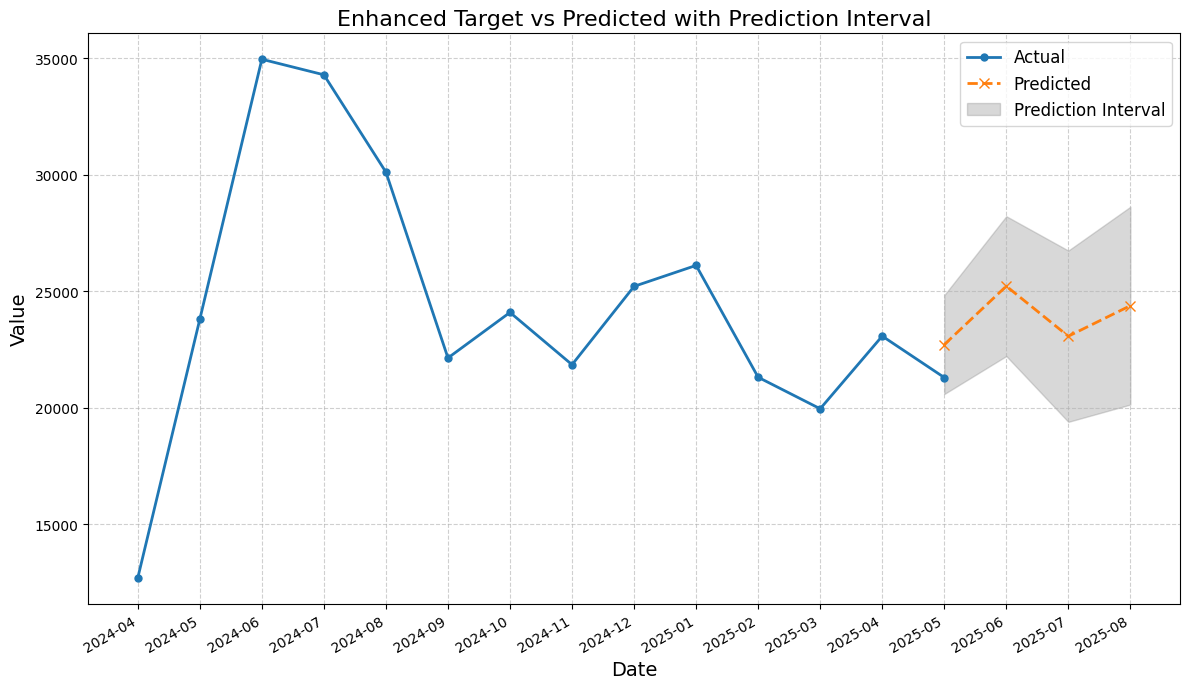

In [108]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))


# Plot actual and predicted values
ax.plot(
    df["year_month"],
    df["target_next_3months"],
    label="Actual",
    marker="o",
    markersize=5,
    linewidth=2,
)
ax.plot(
    df["year_month"],
    df["predicted"],
    label="Predicted",
    marker="x",
    markersize=7,
    linestyle="--",
    linewidth=2,
)

# Fill prediction interval
ax.fill_between(
    df["year_month"],
    df["lower"],
    df["upper"],
    color="gray",
    alpha=0.3,
    label="Prediction Interval",
)

# Improve formatting
ax.set_title("Enhanced Target vs Predicted with Prediction Interval", fontsize=16)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Value", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(fontsize=12, loc="best")

fig.autofmt_xdate()  # Auto-format date labels
plt.tight_layout()
plt.show()

## Delete the batch endpoint and deployment

In [ ]:
# Delete the batch endpoint and compute. Do not do it occasionally.
ml_client.batch_endpoints.begin_delete(name=batch_endpoint_name).wait()
ml_client.compute.begin_delete(name=cluster_name).wait()